<a href="https://colab.research.google.com/github/Fegel12/Unab/blob/main/3_3_Validaci%C3%B3n_cruzada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



<img src="https://d1yjjnpx0p53s8.cloudfront.net/styles/logo-thumbnail/s3/102012/logo_unab.png?itok=hZ5x30O2" width="240" height="240" align="right"/>


<center><h1>Estadística para la Ciencia de Datos</header1></center>
<left><h1>Unidad 3: Modelos predictivos</header1></left>

### Paquetes usados

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#para escalar variables numéricas
from sklearn.preprocessing import MinMaxScaler

#omitir waarnings
import warnings
warnings.filterwarnings('ignore')

# con este codigo vemos todas las cols
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

sns.set(style= 'whitegrid', context='notebook')

# Validación cruzada

**¿Qué es la validación cruzada?**

La validación cruzada *es una técnica utilizada en machine learning para evaluar la capacidad de generalización de un modelo*. Consiste en dividir el conjunto de datos en múltiples subconjuntos o "folds", entrenar el modelo con algunos de ellos y validar su rendimiento con los restantes. Este proceso se repite varias veces, de modo que cada partición del conjunto de datos se utilice tanto para entrenamiento como para validación.

Esta metodología permite:

- Obtener una estimación más robusta del rendimiento del modelo.
- Reducir el sesgo asociado a una única división de entrenamiento/prueba.
- Detectar sobreajuste (overfitting) de manera más confiable.

**¿Qué es K-Fold?**

K-Fold es una de las formas más comunes de validación cruzada. *El conjunto de datos se divide en K particiones (folds) del mismo tamaño*. Luego se realizan K iteraciones, donde en cada una:

- Se entrena el modelo con K−1 folds.
- Se valida con el fold restante.

Finalmente, se calcula el promedio de las métricas de rendimiento obtenidas en cada iteración, lo cual proporciona una estimación más precisa y estable del comportamiento del modelo.

Por ejemplo, en una validación cruzada con K=6, el conjunto de datos se divide en 6 partes. El modelo se entrena 6 veces, usando 5 folds para entrenar y 1 distinto para validar en cada iteración.

Para evaluar los modelos de clasificación tenemos los siguientes:

![Texto alternativo](https://drive.google.com/uc?id=1mJG1ZGLTWdrF6xa8969UF4aA6mXeem41)


De ahí recalcamos esta métrica:

- **F1 Score:** Esta es una métrica muy utilizada en problemas en los que el conjunto de datos a analizar está desbalanceado. Esta métrica combina el precision y el recall, para obtener un valor mucho más objetivo.

$$F1 = 2 * \cfrac{recall * precision}{recall + precision}$$

In [ ]:
import kagglehub

path = kagglehub.dataset_download("blastchar/telco-customer-churn")
df_data = pd.read_csv(f"{path}/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_data.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#pasamos TotalCharges a numérico
df_data.TotalCharges = pd.to_numeric(df_data.TotalCharges, errors='coerce')
# En este caso eliminaremos los nulos
df_data.dropna(inplace=True)
#eliminamos los id
df_data.drop('customerID',axis=1,inplace=True)
#convertimos a numerico la var objetivo 'Churn'
df_data['Churn'].replace(to_replace='Yes', value = 1, inplace=True)
df_data['Churn'].replace(to_replace='No', value = 0, inplace=True)

In [ ]:
df_data_processing = df_data.copy()

Creamos las variables dummy con get_dummies de pandas.

*También se puede hacer con OneHotEncoder() de scikit-learn*

In [ ]:
#aplicamos el get-dummies
df_data_processing = pd.get_dummies(df_data_processing)
df_data_processing = df_data_processing.astype(int)
df_data_processing.sample(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
5543,1,14,78,1043,0,1,0,1,0,1,0,0,1,1,0,0,0,1,0,0,0,1,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0
4214,0,4,90,368,1,0,1,1,0,1,0,0,1,0,0,1,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,1,0
911,1,15,89,1288,0,1,0,1,0,1,0,0,1,0,0,1,0,1,0,1,0,0,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0
1833,0,1,47,47,0,0,1,1,0,1,0,0,1,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,1,0
2718,0,62,43,2618,0,0,1,1,0,1,0,1,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,1,1,0,0,1,0,0,0,0,1,0,1,1,0,0,0


Acá escalamos las variables numericas y ajustamos:

In [ ]:
scaler = MinMaxScaler()
df_data_processing_scaled =  scaler.fit_transform(df_data_processing)
df_data_processing_scaled = pd.DataFrame(df_data_processing_scaled)
df_data_processing_scaled.columns = df_data_processing.columns

Separamos los atriibutos a entrear y la variable objetivo

In [ ]:
# Entrenamiento del modelo
X = df_data_processing_scaled.drop('Churn',axis=1)
y = df_data_processing_scaled['Churn'].values

Separamos los datos como prueba y entrenamiento:

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

Vamos a crear 4 modelos de regresión logística, y a evaluarlos:
- **modelo_1:** Modelo con los hiperparametros por defecto y todos los atributos.
- **modelo_2:** Modelo con los parametros por defecto y haciendo gridsearch en: C, penalty, solver y class_weight, pero con todos los atributos. Para el grid se usará F1 score.
- **modelo_3:** Modelo con hiperparametros por defecto y haciendo seleccion de atributos basado en el p-valor.
- **modelo_4:** Modelo con los hiperparametros  haciendo gridsearch en C, penalty, solver y class_weight, usando F1 score para seleccionar. Y seleccionando atributos con el p-valor.

Es necesario crear una funcion logistica con p-valores:

In [ ]:
from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_p_values:

    def __init__(self, *args, **kwargs):
        self.model = linear_model.LogisticRegression(*args, **kwargs)

    def fit(self, X, y):
        self.model.fit(X, y)

        decision = self.model.decision_function(X)
        denom = (2.0 * (1.0 + np.cosh(decision)))
        denom = np.tile(denom, (X.shape[1], 1)).T

        # Matriz de Fisher (X / denom)' * X
        F_ij = np.dot((X / denom).T, X)

        # Usamos pseudo-inversa en lugar de inversa normal
        try:
            Cramer_Rao = np.linalg.inv(F_ij)
        except np.linalg.LinAlgError:
            Cramer_Rao = np.linalg.pinv(F_ij)

        sigma_estimates = np.sqrt(np.diag(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores]

        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report
import statsmodels.api as sm

# Configuración de validación cruzada
kf = KFold(n_splits=6, shuffle=True, random_state=42)

# Diccionario para guardar métricas por modelo
results = {
    "modelo_1": {"precision": [], "recall": [], "tpr": [], "tnr": []},
    "modelo_2": {"precision": [], "recall": [], "tpr": [], "tnr": []},
    "modelo_3": {"precision": [], "recall": [], "tpr": [], "tnr": []},
    "modelo_4": {"precision": [], "recall": [], "tpr": [], "tnr": []},
}

param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['lbfgs', 'liblinear', 'saga'],
    'class_weight': [None, 'balanced']
}

Para evaluar el desempeño de los distintos modelos de regresión logística propuestos sobre el dataset de churn de Telco, se emplea el método de **validación cruzada con KFold**, utilizando 6 particiones (folds). Esta técnica permite estimar la capacidad de generalización del modelo de forma más robusta, ya que entrena y valida el modelo en diferentes subconjuntos de los datos. En cada iteración, el conjunto de entrenamiento cambia, lo que reduce el sesgo y la varianza del modelo asociados a una única división train/test.

Se comparan cuatro variantes de modelos de regresión logística, diferenciados por el uso o no de ajuste de hiperparámetros mediante búsqueda en cuadrícula (GridSearchCV), así como por la aplicación de selección de atributos basada en p-valores. Para cada modelo, se calculan y grafican métricas clave: precisión (precision), exhaustividad (recall), y las tasas de verdaderos positivos (TPR) y verdaderos negativos (TNR) durante la validación cruzada, permitiendo así evaluar tanto la calidad global como el balance del modelo frente a la clase minoritaria (clientes que abandonan).

Para lo siguiente ajustaremos esta función:

In [ ]:
def evaluar_modelo(nombre, modelo, X_data, y_data):
    for train_idx, val_idx in kf.split(X_data):
        X_train, X_val = X_data.iloc[train_idx], X_data.iloc[val_idx]
        y_train, y_val = y_data[train_idx], y_data[val_idx]

        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_val)

        # Métricas
        precision = precision_score(y_val, y_pred)
        recall = recall_score(y_val, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
        tpr = tp / (tp + fn)
        tnr = tn / (tn + fp)

        # Guardar resultados
        results[nombre]["precision"].append(precision)
        results[nombre]["recall"].append(recall)
        results[nombre]["tpr"].append(tpr)
        results[nombre]["tnr"].append(tnr)

Definimos el modelo 1

In [ ]:
modelo_1 = LogisticRegression(max_iter=1000)
evaluar_modelo("modelo_1", modelo_1, X, y)

Para hacernos una idea de como es este modlo, veamos los p-valores:

In [ ]:
# Logistic regression with balansed weights
reg = LogisticRegression_with_p_values(max_iter=1000)
reg.fit(X_train, y_train)
# Estimates the coefficients of the object from the 'LogisticRegression' class
# with inputs (independent variables) contained in the first dataframe
# and targets (dependent variables) contained in the second dataframe.
feature_name = X_train.columns.values

In [ ]:
summary_table = pd.DataFrame(columns = ['Feature_name'], data = feature_name)
summary_table['Coefficients'] = np.transpose(reg.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table = summary_table.sort_index()
# This is a list.
p_values = reg.p_values
# We take the result of the newly added method 'p_values' and store it in a variable 'p_values'.
# Add the intercept for completeness.
p_values = np.append(np.nan, np.array(p_values))
# We add the value 'NaN' in the beginning of the variable with p-values.
summary_table['p_values'] = p_values
summary_table['Significativa (p<0.05)'] = summary_table['p_values'] < 0.05
# In the 'summary_table' dataframe, we add a new column, called 'p_values', containing the values from the 'p_values' variable.
summary_table

,Feature_name,Coefficients,p_values,Significativa (p<0.05)
0,Intercept,-0.230938,NaN,False
1,SeniorCitizen,0.186734,4.947178e-02,True
2,tenure,-3.016005,6.505199e-11,True
3,MonthlyCharges,-0.091228,9.789873e-01,False
4,TotalCharges,1.232060,5.793116e-02,False
5,gender_Female,-0.061073,5.593934e-01,False
6,gender_Male,-0.085805,4.168070e-01,False
7,Partner_No,-0.055972,6.046944e-01,False
8,Partner_Yes,-0.090906,3.979995e-01,False
9,Dependents_No,0.043864,6.902829e-01,False


Las columnas que cumplen el requisito del p-valor son:

In [ ]:
cols1= summary_table[summary_table['Significativa (p<0.05)'] == True].Feature_name
cols1


,Feature_name
1,SeniorCitizen
2,tenure
13,MultipleLines_No
19,OnlineSecurity_No
28,TechSupport_No
31,StreamingTV_No
34,StreamingMovies_No
37,Contract_Month-to-month
39,Contract_Two year
40,PaperlessBilling_No


Veamos como queda la columna en cuestión

In [ ]:
X1 = cols1.tolist()
X1

['SeniorCitizen',
 'tenure',
 'MultipleLines_No',
 'OnlineSecurity_No',
 'TechSupport_No',
 'StreamingTV_No',
 'StreamingMovies_No',
 'Contract_Month-to-month',
 'Contract_Two year',
 'PaperlessBilling_No',
 'PaymentMethod_Electronic check']

Definimos el modelo 2

In [ ]:
# -------- MODELO 2: GridSearch en hiperparámetros + todas las variables --------
modelo_2 = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, scoring='f1', cv=3)
evaluar_modelo("modelo_2", modelo_2, X, y)

In [ ]:
modelo_2.best_params_

{'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'saga'}

Con estos hiperparametros veamos los p-valores

In [ ]:
# Logistic regression with balansed weights
reg2 = LogisticRegression_with_p_values(C= 0.1, class_weight= 'balanced', penalty= 'l1', solver= 'saga')
reg2.fit(X_train, y_train)
feature_name2 = X_train.columns.values

In [ ]:
summary_table2 = pd.DataFrame(columns = ['Feature_name'], data = feature_name2)
summary_table2['Coefficients'] = np.transpose(reg.coef_)
summary_table2.index = summary_table2.index + 1
summary_table2.loc[0] = ['Intercept', reg.intercept_[0]]
summary_table2 = summary_table2.sort_index()
# This is a list.
p_values2 = reg2.p_values
# We take the result of the newly added method 'p_values' and store it in a variable 'p_values'.
# Add the intercept for completeness.
p_values2 = np.append(np.nan, np.array(p_values2))
# We add the value 'NaN' in the beginning of the variable with p-values.
summary_table2['p_values'] = p_values2
summary_table2['Significativa (p<0.05)'] = summary_table2['p_values'] < 0.05
# In the 'summary_table' dataframe, we add a new column, called 'p_values', containing the values from the 'p_values' variable.
summary_table2

,Feature_name,Coefficients,p_values,Significativa (p<0.05)
0,Intercept,-0.230938,NaN,False
1,SeniorCitizen,0.186734,1.161325e-01,False
2,tenure,-3.016005,2.140240e-09,True
3,MonthlyCharges,-0.091228,1.000000e+00,False
4,TotalCharges,1.232060,1.000000e+00,False
5,gender_Female,-0.061073,1.000000e+00,False
6,gender_Male,-0.085805,1.000000e+00,False
7,Partner_No,-0.055972,9.214909e-01,False
8,Partner_Yes,-0.090906,9.078600e-01,False
9,Dependents_No,0.043864,4.515955e-01,False


In [ ]:
cols2= summary_table2[summary_table2['Significativa (p<0.05)'] == True].Feature_name
cols2

,Feature_name
2,tenure
13,MultipleLines_No
19,OnlineSecurity_No
28,TechSupport_No
37,Contract_Month-to-month
39,Contract_Two year
44,PaymentMethod_Electronic check


In [ ]:
X2 = cols2.tolist()
X2

['tenure',
 'MultipleLines_No',
 'OnlineSecurity_No',
 'TechSupport_No',
 'Contract_Month-to-month',
 'Contract_Two year',
 'PaymentMethod_Electronic check']

Definimos el modelo 3

In [ ]:
# -------- MODELO 3: Selección de variables por p-valor --------
X_sel_3 = X[X1]  # Usamos las columnas que cumplen p < 0.05
# Entrenamiento con hiperparámetros por defecto
modelo_3 = LogisticRegression(max_iter=1000)
# Evaluación con la función que ya tienes definida
evaluar_modelo("modelo_3", modelo_3, X_sel_3, y)

Definimos el modelo 4

In [ ]:
# -------- MODELO 4: GridSearch + selección de variables --------
X_sel_4 = X[X2]  # Usamos las columnas que cumplen p < 0.05
# Entrenamiento con hiperparámetros por defecto
modelo_4 = LogisticRegression(C= 0.1, class_weight= 'balanced', penalty= 'l1', solver= 'saga')
# Evaluación con la función que ya tienes definida
evaluar_modelo("modelo_4", modelo_4, X_sel_4, y)

Veamos los resultados

In [ ]:
# Crear un resumen con el promedio de cada métrica por modelo
resumen = {
    modelo: {
        'Precision promedio': np.mean(m["precision"]),
        'Recall promedio': np.mean(m["recall"]),
        'TNR promedio': np.mean(m["tnr"]),
    }
    for modelo, m in results.items()
}

# Convertir a DataFrame para visualizar como tabla
df_resumen = pd.DataFrame(resumen).T.round(3)
display(df_resumen)

,Precision promedio,Recall promedio,TNR promedio
modelo_1,0.658,0.545,0.897
modelo_2,0.515,0.791,0.730
modelo_3,0.640,0.506,0.897
modelo_4,0.495,0.802,0.703


Creamos una función para gráficar los rendimientos de los modelos:

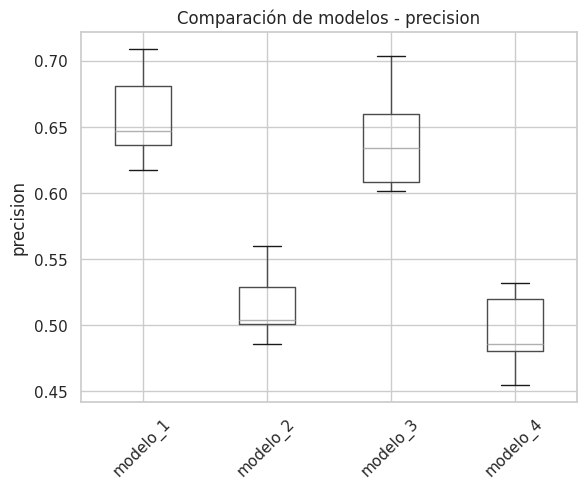

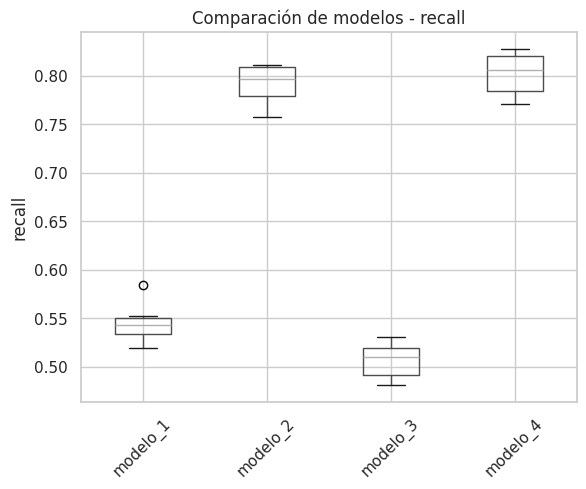

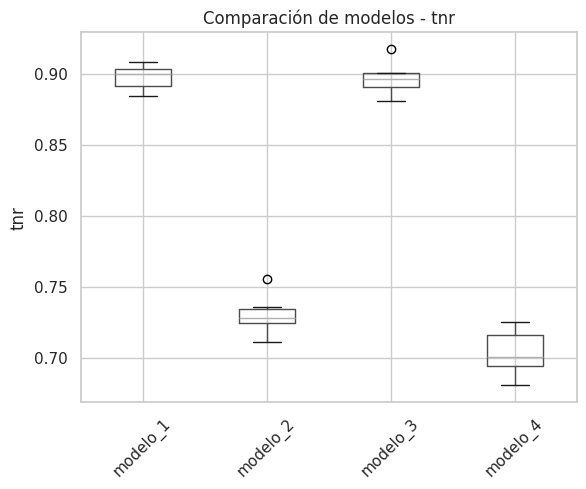

In [ ]:
def plot_metric(metric_name):
    df = pd.DataFrame({k: v[metric_name] for k, v in results.items()})
    df.boxplot()
    plt.title(f'Comparación de modelos - {metric_name}')
    plt.ylabel(metric_name)
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.show()

for metric in ["precision", "recall",  "tnr"]:
    plot_metric(metric)

Para analizar esto, es neecsario ver llo siguiente:

| **Métrica**                     | **Qué mide**                                                              | **Qué evita**               | **Cuándo es más importante**                                                                                                   | **Interpretación general**                                                     |
| ------------------------------- | ------------------------------------------------------------------------- | --------------------------- | ------------------------------------------------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------ |
| **Precision**                   | Proporción de predicciones positivas que son realmente positivas.         | Evita **falsos positivos**. | Cuando **es costoso actuar ante un falso positivo** (ej. contactar a un cliente que no se va, bloquear a un usuario legítimo). | Alta precisión = el modelo **no se equivoca al afirmar que algo es positivo**. |
| **Recall / TPR (Sensibilidad)** | Proporción de positivos reales que fueron correctamente detectados.       | Evita **falsos negativos**. | Cuando **es crítico no dejar escapar un positivo real** (ej. detectar churn, fraude o enfermedad).                             | Alto recall = el modelo **detecta la mayoría de los casos reales**.            |
| **TNR (Especificidad)**         | Proporción de negativos reales correctamente clasificados como negativos. | Evita **falsos positivos**. | Cuando **es importante no etiquetar erróneamente casos negativos** (ej. clientes fieles o transacciones legítimas).            | Alto TNR = el modelo **es bueno en reconocer a los no‑positivos**.             |


Entonces:

- Recall / TPR ➜ mide la capacidad de detección (cuántos positivos reales encuentra el modelo).

- TNR ➜ mide la capacidad de exclusión (qué tan bien evita falsos positivos).

- Precision ➜ mide la fiabilidad de las predicciones positivas.

**En modelos de churn, suele priorizarse un alto Recall (TPR), pero manteniendo un TNR razonable, para no alertar innecesariamente a clientes que no se irán.**